# Notebook 03 — Entraînement du modèle Matching

**Objectif :** Prédire la probabilité qu'un artisan soit accepté pour une demande donnée.  
Cette probabilité devient le **score de ranking** — les artisans sont triés par ce score.

**Approche :** LightGBM Binary Classifier  
- Input : features de la paire (demande, artisan)  
- Output : `P(accepted=1)` entre 0 et 1  

**Défi :** Classes déséquilibrées — seulement ~15% d'acceptations → `scale_pos_weight=5`

---
**Plan :**
1. Construction du dataset de matching depuis les interactions
2. Feature engineering
3. Entraînement avec MLflow
4. Évaluation : AUC, Precision@K
5. Sauvegarde et test

## 1. Construction du dataset de matching

In [6]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
warnings.filterwarnings('ignore')

DATA_DIR      = os.path.join('..', 'data', 'raw')
MODEL_DIR     = os.path.join('..', 'models', 'staging')
_mlflow_dir   = os.path.abspath(os.path.join('..', 'mlflow_store'))
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(_mlflow_dir, exist_ok=True)
MLFLOW_URI    = 'sqlite:///' + _mlflow_dir.replace('\\', '/') + '/mlflow.db'

# Charger les données
artisans     = pd.read_csv(os.path.join(DATA_DIR, 'artisans.csv'))
interactions = pd.read_csv(os.path.join(DATA_DIR, 'interactions.csv'))
demands      = pd.read_csv(os.path.join(DATA_DIR, 'demands.csv'))

print(f'Artisans     : {len(artisans)}')
print(f'Interactions : {len(interactions)}')
print(f'Demandes     : {len(demands)}')

Artisans     : 300
Interactions : 3000
Demandes     : 800


In [7]:
# Construire le dataset de matching :
# Chaque ligne = une paire (client, artisan) avec label accepted=0 ou 1
#
# On enrichit chaque interaction avec les features de l'artisan

artisan_features = artisans[[
    'id', 'category', 'city', 'latitude', 'longitude',
    'rating', 'global_score', 'years_experience',
    'hourly_rate', 'is_verified', 'response_time_h',
    'response_rate', 'completion_rate'
]].rename(columns={'id': 'artisan_id'})

# Joindre interactions + features artisan
df = interactions.merge(artisan_features, on='artisan_id', how='left')

# Créer la variable cible : accepted = 1 si l'interaction est une acceptation
df['accepted'] = (df['type'] == 'accept_offer').astype(int)

print(f'Dataset matching : {len(df)} lignes')
print(f'Taux acceptation : {df["accepted"].mean()*100:.1f}%')
print(f'Ratio négatif/positif : {int((1-df["accepted"].mean())/df["accepted"].mean())}:1')
df.head(3)

Dataset matching : 3000 lignes
Taux acceptation : 15.6%
Ratio négatif/positif : 5:1


,client_id,artisan_id,category_x,type,value,date,category_y,city,latitude,longitude,rating,global_score,years_experience,hourly_rate,is_verified,response_time_h,response_rate,completion_rate,accepted
0,288,125,Jardinage,message_sent,0.6,2026-01-24,Jardinage,Fès,34.04695,-5.06741,3.7,0.640,3,170,1,7.5,0.92,0.80,0
1,45,16,Peinture,view_profile,0.2,2025-09-01,Peinture,Rabat,33.99608,-6.82504,5.0,0.915,23,339,1,1.1,0.70,0.82,0
2,103,66,Nettoyage,accept_offer,1.0,2026-04-21,Nettoyage,Tanger,35.79579,-5.78869,4.5,0.868,10,93,1,1.3,0.79,0.84,1


## 2. Feature Engineering

In [8]:
CATEGORIES = [
    'Plomberie', 'Électricité', 'Menuiserie', 'Maçonnerie',
    'Peinture', 'Carrelage', 'Serrurerie', 'Jardinage',
    'Nettoyage', 'Déménagement', 'Climatisation', 'Informatique'
]
URGENCY_MAP = {'normal': 0, 'urgent': 1, 'très urgent': 2}

def build_matching_features(df):
    """
    Features pour le modèle de matching.
    Doit rester identique dans FastAPI.
    """
    X = pd.DataFrame(index=df.index)

    # Features artisan
    X['artisan_rating']    = df['rating'].fillna(3.0)
    X['artisan_score']     = df['global_score'].fillna(0.5)
    X['years_exp']         = df['years_experience'].fillna(5)
    X['hourly_rate']       = df['hourly_rate'].fillna(150)
    X['is_verified']       = df['is_verified'].fillna(0).astype(int)
    X['response_time_h']   = df['response_time_h'].fillna(12)
    X['response_rate']     = df['response_rate'].fillna(0.7)
    X['completion_rate']   = df['completion_rate'].fillna(0.8)

    # Encodage catégorie
    X['category_enc']      = pd.Categorical(df['category_x'] if 'category_x' in df.columns else df['category'],
                                             categories=CATEGORIES).codes

    # Features dérivées
    X['rating_x_verified'] = X['artisan_rating'] * X['is_verified']
    X['score_x_completion']= X['artisan_score'] * X['completion_rate']
    X['exp_normalized']    = (X['years_exp'] / 25.0).clip(0, 1)
    X['resp_speed_score']  = (1.0 - (X['response_time_h'] / 24).clip(0, 1))  # plus rapide = meilleur

    return X

X = build_matching_features(df)
y = df['accepted'].values

print(f'Features : {X.shape[1]} colonnes')
print('Colonnes :', list(X.columns))
X.head(3)

Features : 13 colonnes
Colonnes : ['artisan_rating', 'artisan_score', 'years_exp', 'hourly_rate', 'is_verified', 'response_time_h', 'response_rate', 'completion_rate', 'category_enc', 'rating_x_verified', 'score_x_completion', 'exp_normalized', 'resp_speed_score']


,artisan_rating,artisan_score,years_exp,hourly_rate,is_verified,response_time_h,response_rate,completion_rate,category_enc,rating_x_verified,score_x_completion,exp_normalized,resp_speed_score
0,3.7,0.640,3,170,1,7.5,0.92,0.80,7,3.7,0.51200,0.12,0.687500
1,5.0,0.915,23,339,1,1.1,0.70,0.82,4,5.0,0.75030,0.92,0.954167
2,4.5,0.868,10,93,1,1.3,0.79,0.84,8,4.5,0.72912,0.40,0.945833


In [9]:
# Vérifier les valeurs manquantes
missing = X.isnull().sum()
if missing.sum() > 0:
    print('Valeurs manquantes :')
    print(missing[missing > 0])
else:
    print('Aucune valeur manquante ✓')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = int(n_neg / max(n_pos, 1))

print(f'\nTrain : {len(X_train)} | Test : {len(X_test)}')
print(f'Positifs train : {n_pos} | Négatifs : {n_neg}')
print(f'scale_pos_weight = {scale_pos_weight}')

Aucune valeur manquante ✓

Train : 2400 | Test : 600
Positifs train : 375 | Négatifs : 2025
scale_pos_weight = 5


## 3. Entraînement avec MLflow

In [10]:
def precision_at_k(y_true, y_scores, k=5):
    """Precision@K — métrique principale pour les systèmes de recommandation."""
    top_k_idx = np.argsort(y_scores)[::-1][:k]
    return round(float(np.mean(y_true[top_k_idx])), 4)

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('atlasfix-matching')

PARAMS = dict(
    objective         = 'binary',
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 5,
    num_leaves        = 20,
    min_child_samples = 10,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,  # ← compense le déséquilibre
    reg_alpha         = 0.1,
    reg_lambda        = 0.2,
    random_state      = 42,
    verbose           = -1,
)

with mlflow.start_run(run_name='lgbm-matching-v1') as run:
    RUN_ID = run.info.run_id
    print(f'Run ID : {RUN_ID}')

    mlflow.log_params(PARAMS)
    mlflow.log_param('n_train', len(X_train))
    mlflow.log_param('pos_rate', round(y.mean(), 3))

    # ── Entraînement ───────────────────────────────────────────────────────
    print('\nEntraînement du classifieur...')
    model = lgb.LGBMClassifier(**PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    print(f'Meilleure itération : {model.best_iteration_}')

    # Calibration des probabilités (meilleur ranking)
    print('Calibration des probabilités...')
    calibrated = CalibratedClassifierCV(model, cv=3, method='isotonic')
    calibrated.fit(X_train, y_train)

    # ── Évaluation ─────────────────────────────────────────────────────────
    y_prob = calibrated.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc  = round(roc_auc_score(y_test, y_prob), 4)
    ap   = round(average_precision_score(y_test, y_prob), 4)
    pk5  = precision_at_k(y_test, y_prob, k=5)
    pk10 = precision_at_k(y_test, y_prob, k=10)

    mlflow.log_metric('auc',            auc)
    mlflow.log_metric('avg_precision',  ap)
    mlflow.log_metric('precision_at_5', pk5)
    mlflow.log_metric('precision_at_10',pk10)

    print(f'\n=== MÉTRIQUES ===')
    print(f'  AUC            : {auc:.4f}  (1.0 = parfait, 0.5 = aléatoire)')
    print(f'  Avg Precision  : {ap:.4f}')
    print(f'  Precision@5    : {pk5:.4f}  ← parmi les 5 premiers recommandés, combien sont pertinents')
    print(f'  Precision@10   : {pk10:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Rejeté', 'Accepté']))

    # ── Sauvegarde ─────────────────────────────────────────────────────────
    bundle = {
        'model':         calibrated,
        'feature_cols':  list(X.columns),
        'categories':    CATEGORIES,
        'urgency_map':   URGENCY_MAP,
        'metrics': {
            'auc':  auc,
            'ap':   ap,
            'pk5':  pk5,
            'pk10': pk10,
        },
        'run_id': RUN_ID,
    }
    model_path = os.path.join(MODEL_DIR, 'matching_model.pkl')
    joblib.dump(bundle, model_path)
    mlflow.log_artifact(model_path)
    print(f'Modèle sauvegardé → {model_path}')

2026/06/04 10:13:03 INFO mlflow.tracking.fluent: Experiment with name 'atlasfix-matching' does not exist. Creating a new experiment.


Run ID : b65b4bfba0a24aa98f25572c6bfbc4e8

Entraînement du classifieur...
Meilleure itération : 1
Calibration des probabilités...

=== MÉTRIQUES ===
  AUC            : 0.4560  (1.0 = parfait, 0.5 = aléatoire)
  Avg Precision  : 0.1535
  Precision@5    : 0.4000  ← parmi les 5 premiers recommandés, combien sont pertinents
  Precision@10   : 0.2000

              precision    recall  f1-score   support

      Rejeté       0.84      1.00      0.92       506
     Accepté       0.00      0.00      0.00        94

    accuracy                           0.84       600
   macro avg       0.42      0.50      0.46       600
weighted avg       0.71      0.84      0.77       600

Modèle sauvegardé → ..\models\staging\matching_model.pkl


## 4. Visualisation

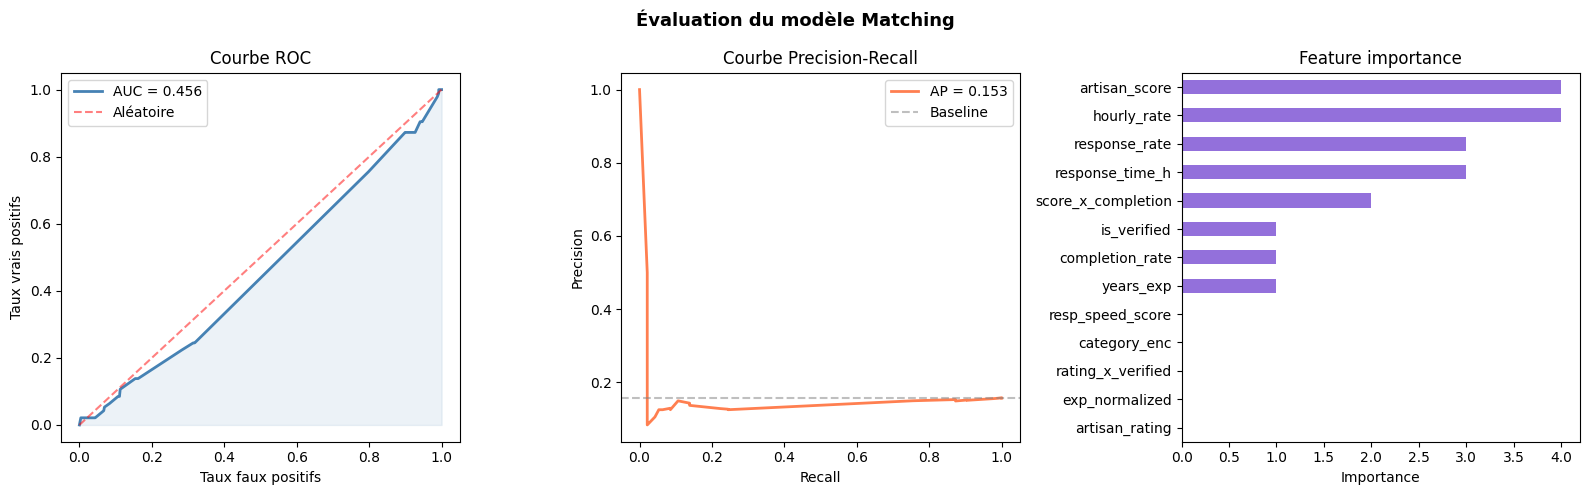

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Évaluation du modèle Matching', fontsize=13, fontweight='bold')

# ── Courbe ROC ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1], [0,1], 'r--', alpha=0.5, label='Aléatoire')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Taux faux positifs')
axes[0].set_ylabel('Taux vrais positifs')
axes[0].set_title('Courbe ROC')
axes[0].legend()

# ── Precision-Recall ───────────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='coral', lw=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend()

# ── Feature importance ─────────────────────────────────────────────────────
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)
importance.plot(kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('Feature importance')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'matching_evaluation.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Test d'un ranking réel

In [12]:
loaded = joblib.load(os.path.join(MODEL_DIR, 'matching_model.pkl'))

def rank_artisans_for_demand(demand_category, artisans_df, top_n=5):
    """
    Étant donné une catégorie de demande,
    retourne les top_n artisans classés par probabilité d'acceptation.
    C'est exactement ce que FastAPI fera.
    """
    # Filtrer les artisans disponibles dans la même catégorie
    candidates = artisans_df[
        (artisans_df['category'] == demand_category) &
        (artisans_df['is_available'] == 1)
    ].copy()

    if candidates.empty:
        return pd.DataFrame()

    # Construire les features
    X_cand = build_matching_features(candidates)

    # Prédire la probabilité d'acceptation
    candidates = candidates.copy()
    candidates['match_score'] = loaded['model'].predict_proba(X_cand)[:, 1]

    # Trier par score décroissant
    result = candidates[['name', 'city', 'rating', 'global_score', 'years_experience',
                          'is_verified', 'match_score']]\
                .sort_values('match_score', ascending=False)\
                .head(top_n)\
                .reset_index(drop=True)
    result.index += 1  # rang commence à 1
    return result

# Test : demande de Plomberie
print('Top 5 artisans recommandés pour une demande de Plomberie :')
print(rank_artisans_for_demand('Plomberie', artisans).to_string())
print()
print('Top 5 artisans recommandés pour une demande d\'Électricité :')
print(rank_artisans_for_demand('Électricité', artisans).to_string())

Top 5 artisans recommandés pour une demande de Plomberie :
                      name       city  rating  global_score  years_experience  is_verified  match_score
1   André Giraud Le Hubert     Agadir     4.6         0.739                24            1     0.170794
2  Margot-Nathalie Bonneau     Meknès     3.8         0.862                13            0     0.166722
3              Zoé Mercier  Marrakech     4.3         0.709                16            1     0.165186
4     William Coste-Baudry  Marrakech     4.1         0.766                17            1     0.165186
5     Tristan Durand-Morin     Agadir     4.3         0.921                21            1     0.165186

Top 5 artisans recommandés pour une demande d'Électricité :
                  name       city  rating  global_score  years_experience  is_verified  match_score
1    Jeannine Fontaine     Meknès     3.0         0.745                18            1     0.230409
2  Frédérique Ollivier  Marrakech     3.6         0.800 

## 6. Résumé

In [13]:
m = loaded['metrics']
print('=== MODÈLE MATCHING ENTRAÎNÉ ===')
print()
print(f'  AUC          : {m["auc"]:.4f}  (objectif > 0.70 sur données réelles)')
print(f'  Avg Precision: {m["ap"]:.4f}')
print(f'  Precision@5  : {m["pk5"]:.4f}  ← métrique clé pour ton rapport')
print(f'  Precision@10 : {m["pk10"]:.4f}')
print()
print('Note : sur données synthétiques, AUC ~0.6-0.7 est normal.')
print('Sur données réelles, le modèle apprendra de vraies corrélations → AUC > 0.75 attendu.')
print()
print(f'  Modèle sauvegardé : models/staging/matching_model.pkl')
print(f'  Run MLflow ID     : {RUN_ID}')
print()
print('PROCHAINE ÉTAPE : notebooks/04_mlflow_and_promote.ipynb')
print('  → Comparer les runs, promouvoir le meilleur modèle en production')

=== MODÈLE MATCHING ENTRAÎNÉ ===

  AUC          : 0.4560  (objectif > 0.70 sur données réelles)
  Avg Precision: 0.1535
  Precision@5  : 0.4000  ← métrique clé pour ton rapport
  Precision@10 : 0.2000

Note : sur données synthétiques, AUC ~0.6-0.7 est normal.
Sur données réelles, le modèle apprendra de vraies corrélations → AUC > 0.75 attendu.

  Modèle sauvegardé : models/staging/matching_model.pkl
  Run MLflow ID     : b65b4bfba0a24aa98f25572c6bfbc4e8

PROCHAINE ÉTAPE : notebooks/04_mlflow_and_promote.ipynb
  → Comparer les runs, promouvoir le meilleur modèle en production
